# Simulation with parameters used from papers
- https://link.springer.com/article/10.1023/A:1008840904246


Parameters required from literature
- X0 
- S0
- Ks
- mu_max
- mue_max
- Yxs

From the above paper, parameters found for glucoamylase production 
- X0:      **10^5 cells/ml**       Converted to   **0.7 CDWg/L**     (Estimated conversion)
- S0 :     **5 m mol/L**           converted to   **0.005 mol/L**    ()
- Mu_max : **0.2 /h**
- Yxs :    **210 CDW g/mol**  

From https://static-content.springer.com/esm/art%3A10.1007%2Fs12257-020-0153-z/MediaObjects/12257_2020_153_MOESM1_ESM.pdf parameters found 
- Ks :      **0.1 g/L**                      converted to    **0.0005 mol/L**   (Calculated conversion, molecular weight of glucose = 180.156 g/mol)
- Mue_max : **8.865 Lactate g/CDW g**        converted to    **8.865 U/CDW g**    (Needs to be adjusted)


# Fed Batch Simulation 

substrate transfer moles:  0.0075


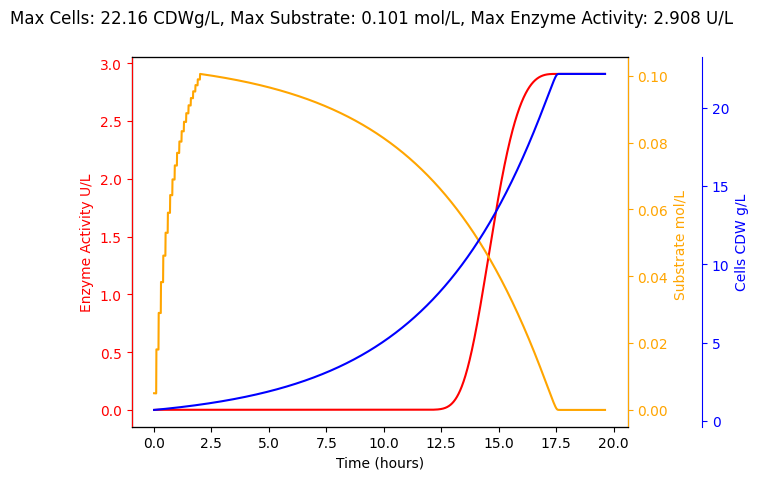

Initial substrate to cell ratio:  7142.857142857143


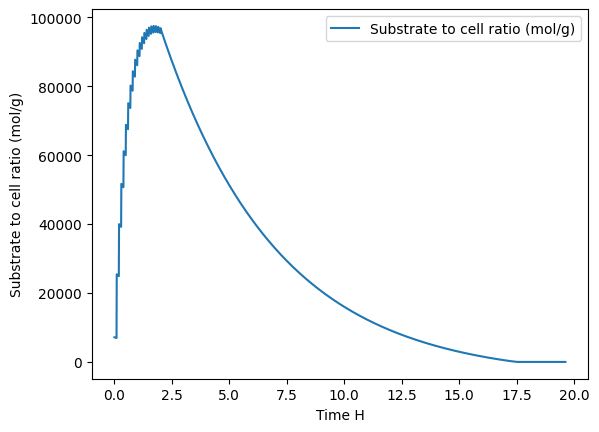

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']


# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 
print("substrate transfer moles: ",substrate_transfer_moles)

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0


for i in range(ns):

    MuX =  mu_max*(math.exp(-((T_opt - T_opt)**2)/config.OPT_TEMP_RANGE**2))
    
    # new cells that are generated
    dXdt = MuX * ( D[i][1] / (Ks + D[i][1])) * D[i][0]

    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    
    # Find change in cells 
    delX = dXdt * del_t
    # Find change in substrate
    delS = dSdt * del_t

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            substrate_action = random.randint(0, 1)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = D[i][1]
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + substrate_transfer_moles  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                D[i][1] = substrate_concentration

    # Check if substrate is less than or close to 0
    if D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = D[i][1] + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0]
    sub_cell_ratio = sub_cell_ratio * 1e6

    if sub_cell_ratio > 10000:
        weibull = 0
    else:
        weibull = cs(sub_cell_ratio)
    MuE = MuE_opt * weibull

    D[i][5] = MuE
    #print(f"when S/X = {sub_cell_ratio}, weibull is : {cs(sub_cell_ratio)}")

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
        break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()



# Batch mode

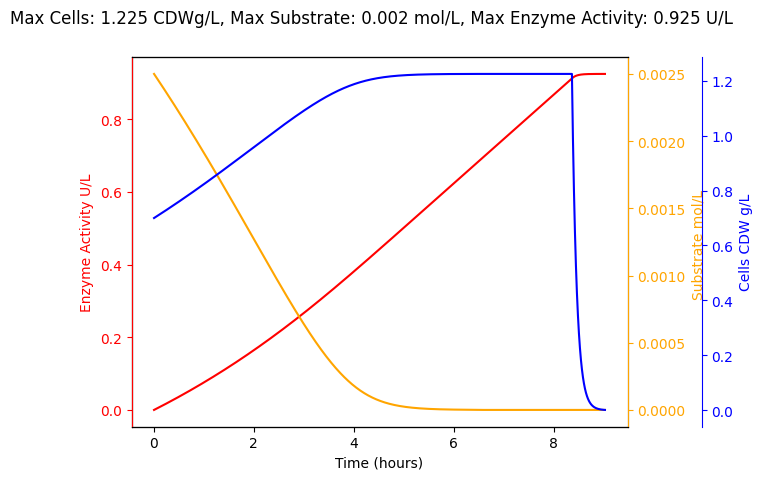

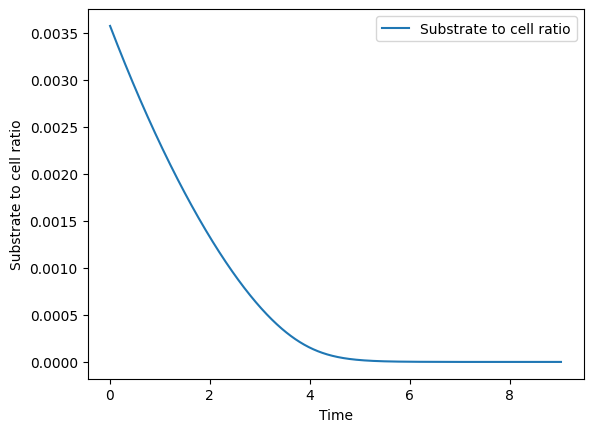

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
sub_in_tank = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_amount = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = sub_in_tank
D[0][2] = E0

cells_produced = []
substrate_death = []

for i in range(ns):

    MuX =  mu_max*(math.exp(-((T_opt - T_opt)**2)/config.OPT_TEMP_RANGE**2))
    
    # new cells that are generated
    dXdt = MuX * ( D[i][1] / (Ks + D[i][1] )) * D[i][0]
    
    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    
    # Find change in cells 
    delX = dXdt * del_t

    # Find change in substrate
    delS = dSdt * del_t

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX

    # # Update substrate
    # if substrate_in_tank_liters < max_substrate_limit_liters:
    #     if i%(media_transfer_step) == 0 and i!= 0:
    #             substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
    #             sub_in_tank = sub_in_tank + substrate_transfer_amount  # grams
    #             substrate_concentration = sub_in_tank/substrate_in_tank_liters # substrate grams/liter
    #             delS = delS + substrate_concentration

    # Check if substrate is less than 0
    if D[i][1] + delS < 0 or D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = D[i][1] + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0] 
    MuE = MuE_opt*(math.exp(-((sub_cell_ratio - config.OPT_SUB_CELL_RATIO)**2)/config.SCR_VIABLE_RANGE**2))
    D[i][5] = MuE

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE

    # terminate if tank capacity is full and cells start dying
    # if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
    #     break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio")
plt.xlabel("Time")
plt.ylabel("Substrate to cell ratio")
plt.legend()



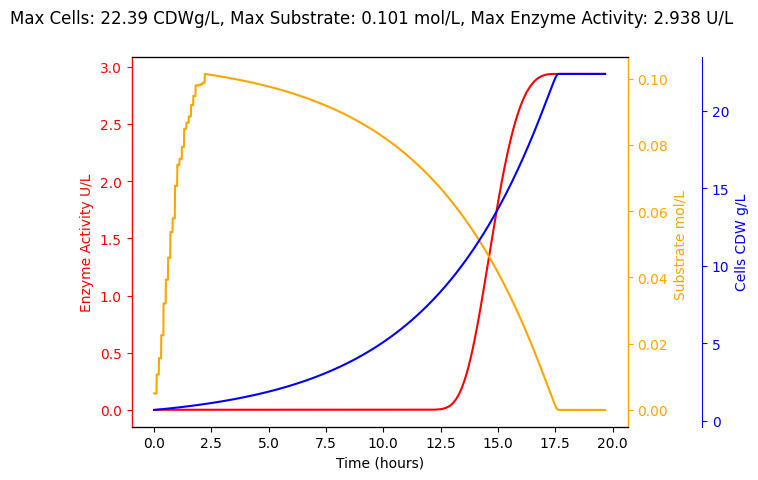

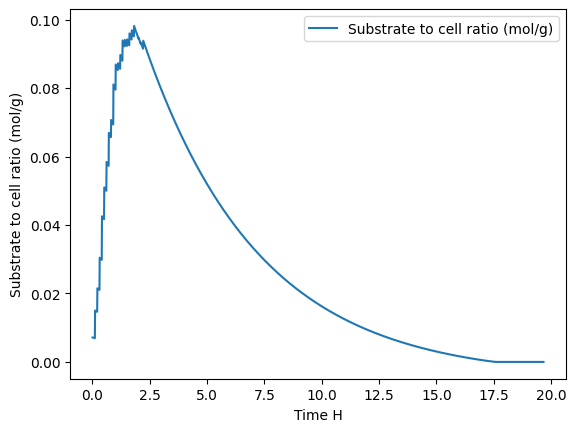

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']


# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 


# 0 1 2  3     4   5      6    7  8    9   10    11
# X S E delE delX, muE, delS, sa, sv, csm, nam, nsc  
D = np.zeros((ns+1, 12))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

csv_data = {
    'timestep': 0,
    'cells': 0,
    'substrate_conc': 0,
    'enzymes': 0,
    'substrate_consumed' : 0,
    'substrate_action': 0,
    'substrate_volume': 0,
    'current_substrate_moles': 0,
    'added_moles': 0,
    'new_sub_conc': 0
    }

timesteps = []
for i in range(ns):
    timesteps.append(i)
    MuX =  mu_max*(math.exp(-((T_opt - T_opt)**2)/config.OPT_TEMP_RANGE**2))
    
    # new cells that are generated
    dXdt = MuX * ( D[i][1] / (Ks + D[i][1])) * D[i][0]

    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    
    # Find change in cells 
    delX = dXdt * del_t
    # Find change in substrate
    delS = dSdt * del_t
    # Store substrate consumed
    D[i][6] = delS

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX

    substrate_concentration = D[i][1]
    #print("Previous substrate conc: ",substrate_concentration)
    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i!=0:
            substrate_action = random.uniform(0, 0.1)
            #print("substrate action ", substrate_action)
            #print("Substrate in tank: ", substrate_in_tank_liters)
            D[i][7] = substrate_action
            # get substrate concentraion for current timestep
            sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
            D[i][9] = sub_in_tank_moles
            # Add substrate and calculate new concentraion
            substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
            #print("New substrate volume: ",substrate_in_tank_liters)
            D[i][8] = substrate_in_tank_liters
            sub_in_tank_moles = sub_in_tank_moles + (substrate_action * ext_tank_substrate_conc)  # grams
            D[i][10] = substrate_transfer_moles
            substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
            D[i][11] = substrate_concentration
            #print("New added Substrate concentration: ",substrate_concentration)

        else:
            D[i][8] = substrate_in_tank_liters
    else:
        D[i][8] = substrate_in_tank_liters
        
        
    # Check if substrate is less than or close to 0
    if D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = substrate_concentration + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0]
    sub_cell_ratio = sub_cell_ratio * 1e6

    if sub_cell_ratio > 10000:
        weibull = 0
    else:
        weibull = cs(sub_cell_ratio)
    MuE = MuE_opt * weibull

    D[i][5] = MuE
    #print(f"when S/X = {sub_cell_ratio}, weibull is : {cs(sub_cell_ratio)}")

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE


    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
        #print(timesteps)
        break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        #print(timesteps)
        break

# 0 1 2  3     4   5      6    7  8  9
# X S E delE delX, muE, delS, sa, sv,sm

timesteps.pop()
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
delS = D[:,6][0:i]
sa = D[:,7][0:i]
sv = D[:,8][0:i]
sm = D[:,9][0:i]
am = D[:,10][0:i]
nc = D[:,11][0:i]

MUE = D[:,5][0:i]
S_C_R = S/X

csv_data['timestep'] = timesteps
csv_data['cells'] = X
csv_data['substrate_conc'] = S
csv_data['enzymes'] = E
csv_data['substrate_consumed'] = delS
csv_data['substrate_action'] = sa
csv_data['substrate_volume'] = sv
csv_data['current_substrate_moles'] = sm
csv_data['added_moles'] = am
csv_data['new_sub_conc'] = nc


# for key, value in csv_data.items():
#     print(len(value))

df = pd.DataFrame(csv_data)

df.to_csv('sub_flow_check.csv')

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()



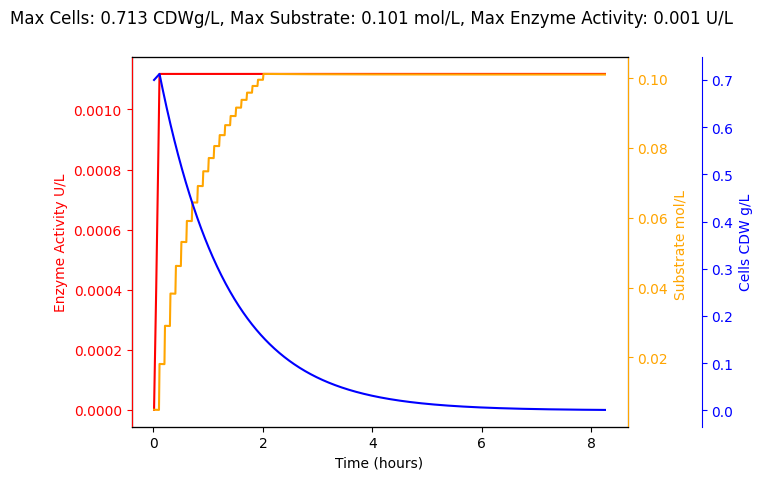

Initial substrate to cell ratio:  7142.857142857143


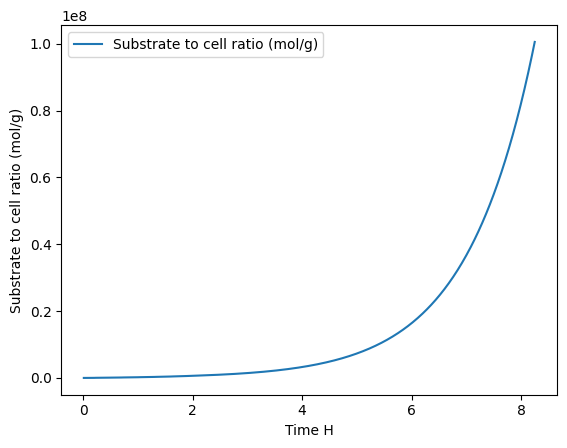

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']


# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 
#print("substrate transfer moles: ",substrate_transfer_moles)

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0


for i in range(ns):

    if D[i][1] > 0.010:
        D[i][0] = D[i][0] - D[i][0]*0.01

     # Calculate MuX for the current timestep based on temperature
    MuX = mu_max * (math.exp(-((T_opt - T_opt)**2) / config.OPT_TEMP_RANGE**2))
    
    # Calculate new cells produced (dXdt) based on current substrate concentration
    dXdt = MuX * (D[i][1] / (Ks + D[i][1])) * D[i][0]

    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    
    # Find change in cells 
    delX = dXdt * del_t
    # Find change in substrate
    delS = dSdt * del_t

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX


    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            substrate_action = random.randint(0, 1)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = D[i][1]
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + substrate_transfer_moles  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                D[i][1] = substrate_concentration

    # Check if substrate is less than or close to 0
    if D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = D[i][1] + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0]
    sub_cell_ratio = sub_cell_ratio * 1e6

    if sub_cell_ratio > 10000:
        weibull = 0
    else:
        weibull = cs(sub_cell_ratio)
    MuE = MuE_opt * weibull

    D[i][5] = MuE
    #print(f"when S/X = {sub_cell_ratio}, weibull is : {cs(sub_cell_ratio)}")

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
        break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()



Text(0.5, 1.0, 'Best substrate: 0.00022422422422422423')

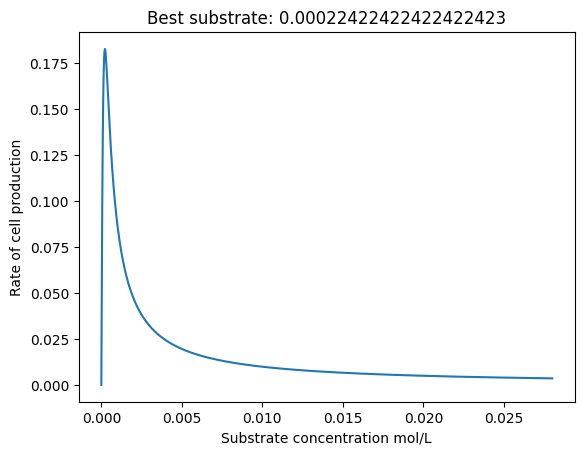

In [13]:
import numpy as np
import matplotlib.pylab as plt

substrs = np.linspace(0, 0.028, 1000)
rates = []
Ks = 0.0005 
inhib = 0.0001
for S in substrs:
    rate_cell =  S / (Ks + S + (S**2/inhib))
    rates.append(rate_cell)

max_cell_rate_indx = rates.index(max(rates))
plt.plot(substrs, rates)
plt.xlabel("Substrate concentration mol/L")
plt.ylabel("Rate of cell production")
plt.title(f"Best substrate: {substrs[max_cell_rate_indx]}")

rate before  0.0
rate before  0.05308056872037914
rate before  0.10081008100810082
rate before  0.14395886889460155
rate before  0.1831561733442355
rate before  0.21892103205629396
rate before  0.251685393258427
rate before  0.2818116462976276
rate before  0.30960608154803043
rate before  0.3353293413173653
rate before  0.359204618345093
rate before  0.3814241486068112
rate before  0.40215439856373425
rate before  0.42154024319629413
rate before  0.43970835670218733
rate before  0.45676998368678634
rate before  0.47282321899736146
rate before  0.4879548949256791
rate before  0.5022421524663677
rate before  0.515753756665051
rate before  0.5285512033978291
rate before  0.5406896551724137
rate before  0.5522187359928283
rate before  0.5631832094446872
rate before  0.5736235595390524
rate before  0.5835764902042517
rate before  0.5930753564154786
rate before  0.6021505376344086
rate before  0.6108297623685236
rate before  0.6191383911551659
rate before  0.6270996640537515
rate before  0.6

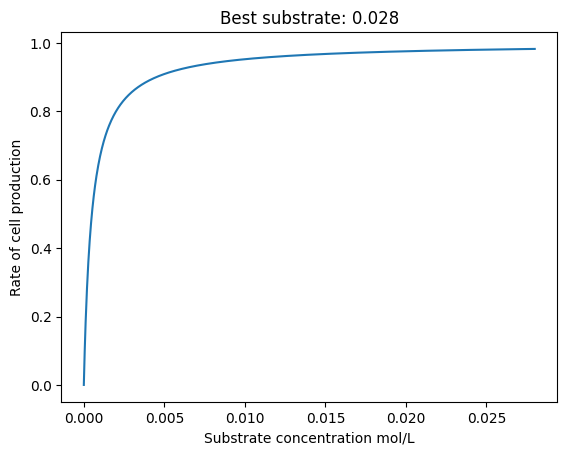

In [14]:
import numpy as np
import matplotlib.pylab as plt

substrs = np.linspace(0, 0.028, 1000)  # Range of substrate concentrations
rates = []  # List to store the rates
Ks = 0.0005  # Saturation constant
inhib = 0.00001  # Inhibition factor

for S in substrs:
    rate_cell = S / (Ks + S)  # Normal rate calculation based on Monod equation
    print("rate before ",rate_cell)
    # If the substrate concentration exceeds 0.015, apply an inhibition factor
    if S > 0.015:
        rate_cell *= (1- inhib * (S - 0.015))  # Decrease rate_cell as S increases
        print("rate after ",rate_cell)
    
    rates.append(rate_cell)  # Append the rate to the list

# Find the index of the maximum cell production rate
max_cell_rate_indx = rates.index(max(rates))

# Plot the substrate concentration vs. rate of cell production
plt.plot(substrs, rates)
plt.xlabel("Substrate concentration mol/L")
plt.ylabel("Rate of cell production")
plt.title(f"Best substrate: {substrs[max_cell_rate_indx]}")
plt.show()


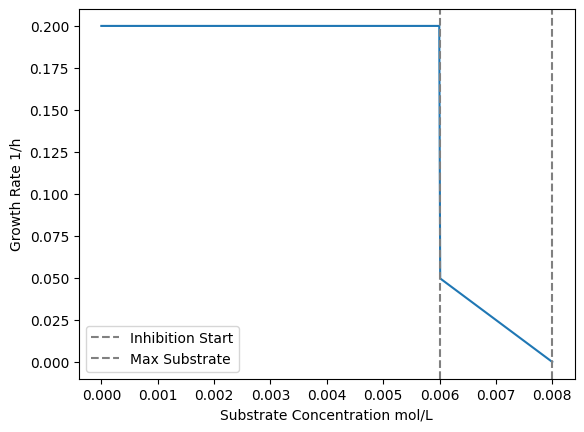

In [15]:
import numpy as np
import config
import matplotlib.pyplot as plt

inhibition_start = 0.006
s_max = 0.008
s_min = 0.00
mu_max = config.MU_MAX
substrate = np.linspace(0,0.008, 500)
rates = []

for S in substrate:
    if S < inhibition_start:
        rates.append(mu_max)
    elif S > inhibition_start and S <= s_max:
        mu = mu_max * (s_max - S)/(s_max - s_min)
        rates.append(mu)
    else:
        rates.append(0)

plt.plot(substrate, rates)
plt.xlabel("Substrate Concentration mol/L")
plt.ylabel("Growth Rate 1/h")
plt.axvline(x=inhibition_start, color='gray', linestyle='--', label="Inhibition Start")
plt.axvline(x=s_max, color='gray', linestyle='--', label="Max Substrate")
plt.legend()



substrate transfer moles:  0.0075


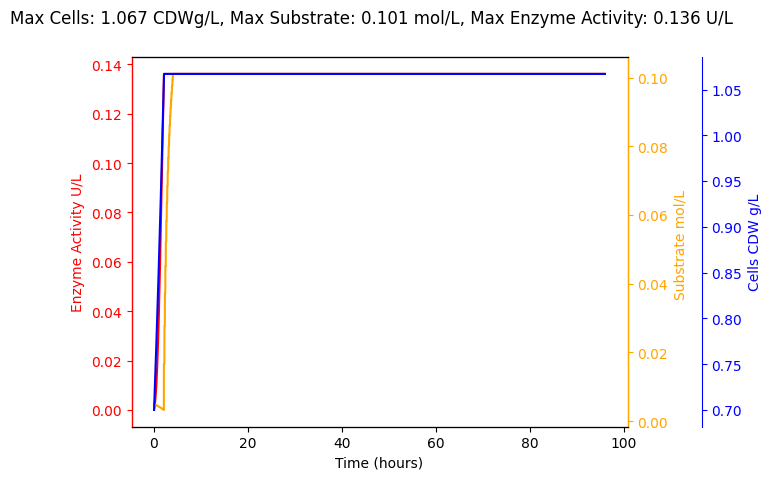

Initial substrate to cell ratio:  7142.857142857143


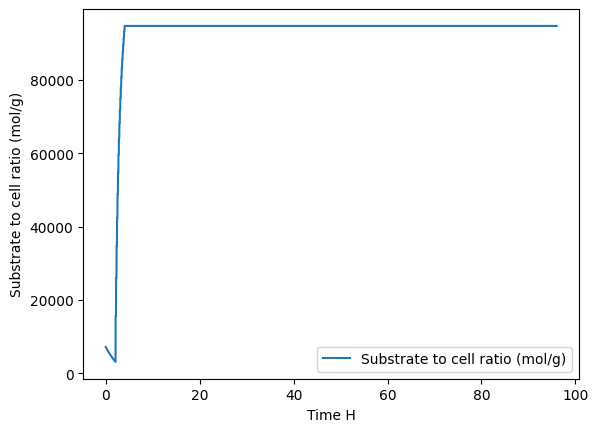

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']


# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

inhibition_start = 0.006
s_max = 0.008
s_min = 0.001
MuXs = []
cells_produced = []

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 
print("substrate transfer moles: ",substrate_transfer_moles)

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0


for i in range(ns):
    
    if D[i][1] < inhibition_start:
        MuX = mu_max
    elif D[i][1] > inhibition_start and D[i][1] <= s_max:
        MuX = mu_max * (s_max - D[i][1])/(s_max - s_min)
    else:
        MuX = 0
    
    MuXs.append(MuX)
    # new cells that are generated
    dXdt = MuX * D[i][0]
    

    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    
    # Find change in cells 
    delX = dXdt * del_t
    cells_produced.append(dXdt)
    # Find change in substrate
    delS = dSdt * del_t

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i > 200 :
            substrate_action = random.randint(0, 1)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = D[i][1]
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + substrate_transfer_moles  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                D[i][1] = substrate_concentration

    # Check if substrate is less than or close to 0
    if D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = D[i][1] + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0]
    sub_cell_ratio = sub_cell_ratio * 1e6

    if sub_cell_ratio > 10000:
        weibull = 0
    else:
        weibull = cs(sub_cell_ratio)
    MuE = MuE_opt * weibull

    D[i][5] = MuE
    #print(f"when S/X = {sub_cell_ratio}, weibull is : {cs(sub_cell_ratio)}")

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
        break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()



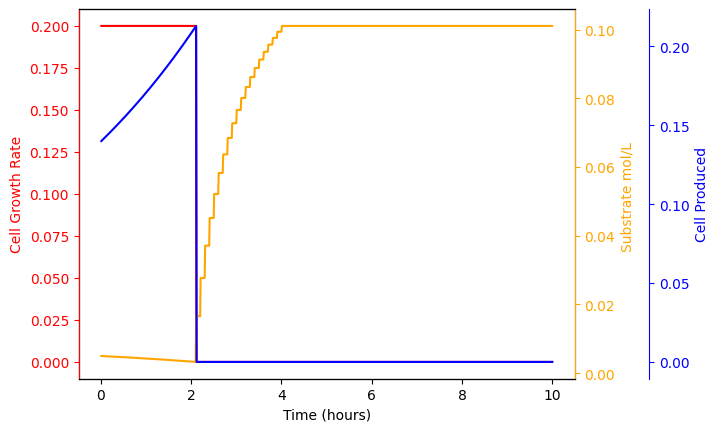

In [17]:
fig, ax1 = plt.subplots()
#fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:1000] , MuXs[0:1000] ,color="red", label= "Cell Growth Rate")

ax2 = ax1.twinx()
ax2.plot(tvec[0:1000], S[0:1000], color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:1000] , cells_produced[0:1000] ,color="blue", label="Cells Produced")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Cell Growth Rate", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cell Produced", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

# Cell production curve

Text(0, 0.5, 'Growth Rate 1/h')

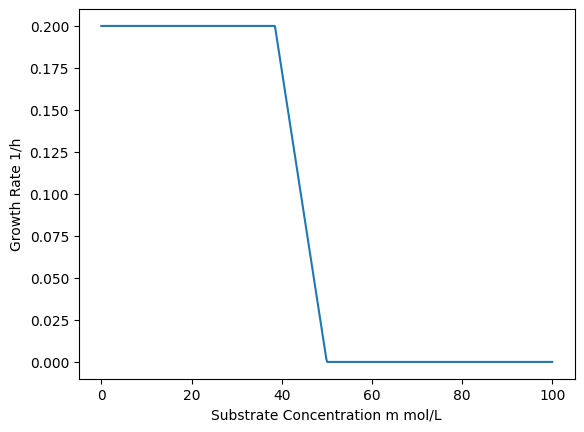

In [18]:
import numpy as np
import config
import matplotlib.pyplot as plt

mu_max = config.MU_MAX
substrate = np.linspace(0,0.1, 500)
rates = []

for S in substrate:
    if S < config.S_MIN:
        mu = mu_max
    elif S >= config.S_MIN and S <= config.S_MAX:
        mu = mu_max * (config.S_MAX - S)/(config.S_MAX - config.S_MIN)
    else:
        mu = 0
    rates.append(mu)

plt.plot(substrate*1000, rates)
plt.xlabel("Substrate Concentration m mol/L")
plt.ylabel("Growth Rate 1/h")




# Logistic implementation

Text(0, 0.5, 'Growth Rate 1/h')

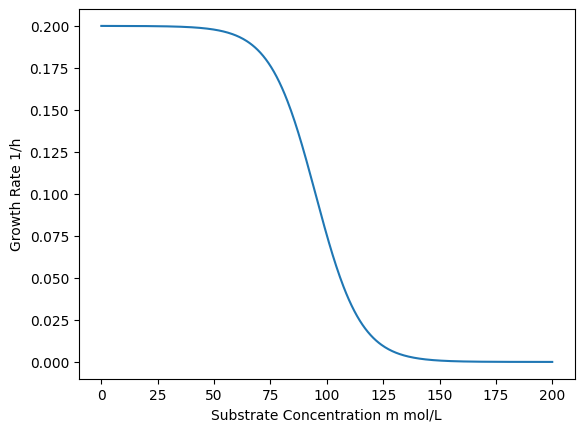

In [26]:
import numpy as np
import config
import matplotlib.pyplot as plt

def logistic(substrate, L=config.MU_MAX, k=100, t0=0.095):
    """
    Logistic function for cell production rate where:
    - substrate: input concentration (mol/L)
    - L: maximum production rate (0.20 in this case)
    - k: steepness of the curve (adjust for desired fall-off)
    - t0: midpoint concentration (adjust to match the substrate range)
    """
    return L * (1 - (1 / (1 + np.exp(-k * (substrate - t0)))))



# Compute the cell production rate from the logistic curve
L = 0.20  # Maximum production rate (desired to start at 0.20)
k = 250   # Steepness, adjusted to the new substrate range
t0 = 0.07 # Midpoint adjusted between 0.038 and 0.1 mol/L

mu_max = config.MU_MAX
substrate = np.linspace(0,0.2, 500)
rates = []

for S in substrate:
    mu = logistic(S)
    rates.append(mu)

plt.plot(substrate*1000, rates)
plt.xlabel("Substrate Concentration m mol/L")
plt.ylabel("Growth Rate 1/h")

# Logistic cell production rate

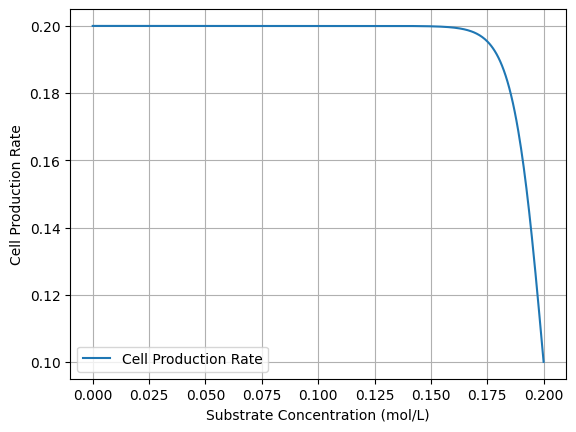

Cell production rate for substrate concentration 0.2 mol/L: 0.1


In [85]:
import numpy as np
import matplotlib.pyplot as plt

# Define the logistic function for cell production rate
def logistic(substrate, L=config.MU_MAX, k=100, t0=0.095):
    """
    Logistic function for cell production rate where:
    - substrate: input concentration (mol/L)
    - L: maximum production rate (0.20 in this case)
    - k: steepness of the curve (adjust for desired fall-off)
    - t0: midpoint concentration (adjust to match the substrate range)
    """
    return L * (1 - (1 / (1 + np.exp(-k * (substrate - t0)))))

# Substrate concentration range between 0.038 and 0.1 mol/L
substrate_concentrations = np.linspace(0, 0.2, 500)

# Compute the cell production rate from the logistic curve
L = 0.20  # Maximum production rate (desired to start at 0.20)
k = 150   # Steepness, adjusted to the new substrate range
t0 = 0.20 # Midpoint adjusted between 0.038 and 0.1 mol/L
cell_production_rate = logistic(substrate_concentrations, L, k, t0)

# Plot the logistic function
plt.plot(substrate_concentrations, cell_production_rate, label='Cell Production Rate')
plt.xlabel('Substrate Concentration (mol/L)')
plt.ylabel('Cell Production Rate')
plt.grid(True)
plt.legend()
plt.show()

# Example: Get the cell production rate for a specific substrate concentration
substrate_input = 0.2  # Input substrate concentration (mol/L)
rate = logistic(substrate_input, L, k, t0)
print(f"Cell production rate for substrate concentration {substrate_input} mol/L: {rate}")


# Refreshed Simulation

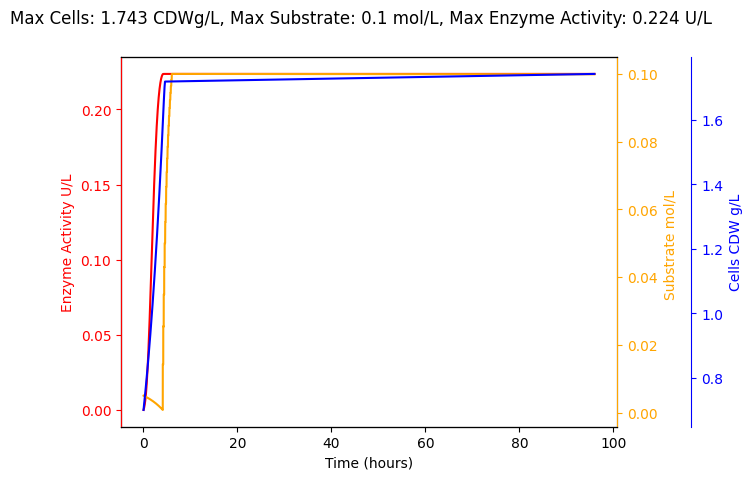

Initial substrate to cell ratio:  7142.857142857143


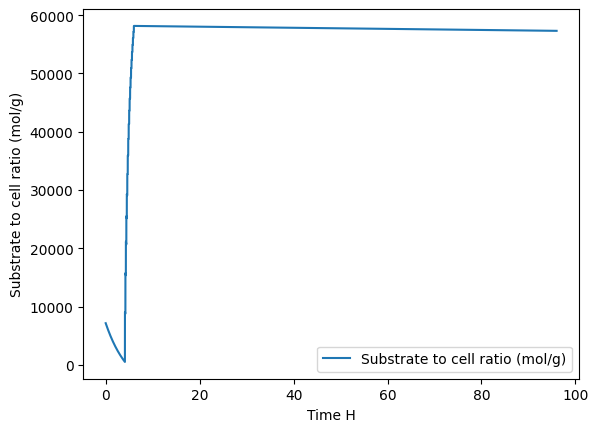

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)


# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0


for i in range(ns):

    #MuX =  mu_max*(math.exp(-((T_opt - T_opt)**2)/config.OPT_TEMP_RANGE**2))
    if D[i][1] < config.S_MIN:
        MuX = mu_max
    elif D[i][1] >= config.S_MIN and D[i][1] <= config.S_MAX:
        MuX = mu_max * (config.S_MAX - D[i][1])/(config.S_MAX - config.S_MIN)

    # new cells that are generated
    dXdt = MuX * D[i][0]

    # SUbstrate consumption
    dSdt = -(1/Yxs)* dXdt 

    # Find change in cells 
    delX = dXdt * del_t
    # Find change in substrate
    delS = dSdt * del_t

    # Store Change in cells
    D[i+1][4] = delX

    # Update cells
    D[i+1][0] = D[i][0] + delX

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i > 400:
            substrate_action = random.randint(0, 1)
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = D[i][1]
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_transfer_amount_liters # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + substrate_transfer_moles  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                D[i][1] = substrate_concentration

    # Check if substrate is less than or close to 0
    if D[i][1] + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = D[i][1] + delS

    # Cells start dying if no substrate for more than 2 hours
    if D[i+1][1] == 0:
        cell_death_timer += 1
    else:
        cell_death_timer = 0
    
    # if cell_death_timer == 2 hours then cells start dying
    if int(cell_death_time/del_t) <= int(cell_death_timer):
        D[i+1][0] = D[i+1][0] - (D[i+1][0]*0.10)

    # Enzyme determination 
    sub_cell_ratio = D[i][1]/D[i][0]
    sub_cell_ratio = sub_cell_ratio * 1e6

    if sub_cell_ratio > 14000:
        weibull = 0
    else:
        weibull = cs(sub_cell_ratio)
    MuE = MuE_opt * weibull

    D[i][5] = MuE

    # new enzyme from fresh cells
    delE = MuE * D[i][0] * del_t

    # Change in enzyme    
    D[i+1][3] = delE
    
    #Update enzyme variable
    D[i+1][2] = D[i][2] + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and int(cell_death_timer) >= int(cell_death_time/del_t):
        break

    if D[i+1][0] <= 0.001:
        D[i+1][0] = 0
        break
    
X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
S_C_R = S_C_R * 1e6

max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)

'''
================================================================================================================================================
                                                     Plotting      
================================================================================================================================================
'''

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Cells: {max_cells} CDWg/L, Max Substrate: {sub_max} mol/L, Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.15))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time (hours)")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
#fig.legend()
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label="Substrate to cell ratio (mol/g)")
print("Initial substrate to cell ratio: ",S_C_R[0])
plt.xlabel("Time H")
plt.ylabel("Substrate to cell ratio (mol/g)")
plt.legend()

# Monod + Logistic

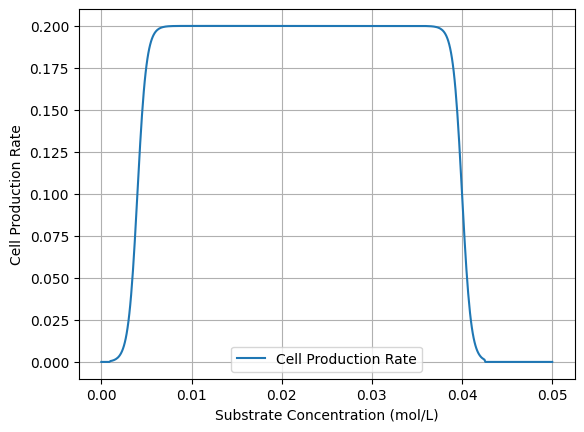

In [180]:
import numpy as np
import matplotlib.pyplot as plt
import config

def monod(S, Ks=config.KS):
    return config.MU_MAX * (S/(Ks + S))

def cell_production_rate(sub_conc, R_max=0.20, S_0=0.004, k=2000):
    """
    Calculate the rate of cell production based on a sigmoid curve.

    Parameters:
    sub_conc (float): Substrate concentration (mol/L).
    R_max (float): Maximum rate of cell production (default is 0.20).
    S_0 (float): Midpoint substrate concentration, where rate is half of R_max (default is 0.025 mol/L).
    k (float): Steepness of the curve. A higher value makes the curve steeper (default is 50).

    Returns:
    float: Rate of cell production.
    """
    # Sigmoid curve formula for rate of cell production
    rate = R_max / (1 + np.exp(-k * (sub_conc - S_0)))
    return rate

# Define the logistic function for cell production rate
def logistic(substrate, L=config.MU_MAX, k=100, t0=0.095):
    """
    Logistic function for cell production rate where:
    - substrate: input concentration (mol/L)
    - L: maximum production rate (0.20 in this case)
    - k: steepness of the curve (adjust for desired fall-off)
    - t0: midpoint concentration (adjust to match the substrate range)
    """
    return L * (1 - (1 / (1 + np.exp(-k * (substrate - t0)))))

# Substrate concentration range between 0.038 and 0.1 mol/L
substrate_concentrations = np.linspace(0, 0.05, 500)

# Compute the cell production rate from the logistic curve
L = 0.20  # Maximum production rate (desired to start at 0.20)
k = 2000   # Steepness, adjusted to the new substrate range
t0 = 0.04 # Midpoint adjusted between 0.038 and 0.1 mol/L

Ks = 0.0003
rates = []

for sub in substrate_concentrations:
    if sub < 0.030 and sub >= 0.0010:
        rate = cell_production_rate(sub)
    elif sub < 0.001:
        rate = 0
    elif sub >= 0.030 and sub <= 0.0425:
        rate = logistic(sub, L, k, t0)
    elif sub > 0.0425:
        rate = 0
    rates.append(rate)

# Plot the logistic function
plt.plot(substrate_concentrations, rates, label='Cell Production Rate')
plt.xlabel('Substrate Concentration (mol/L)')
plt.ylabel('Cell Production Rate')
plt.grid(True)
plt.legend()
plt.show()




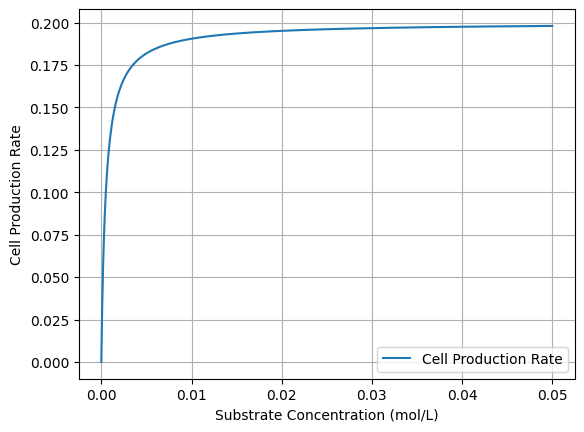

0.004878048780487805

In [122]:
import numpy as np
import matplotlib.pyplot as plt

def monod(S, Ks):
    return 0.2 * (S/(Ks + S))

# Substrate concentration range between 0.038 and 0.1 mol/L
substrate_concentrations = np.linspace(0, 0.050, 500)


Ks = 0.0005
cell_production_rate = monod(substrate_concentrations, Ks)

# Plot the logistic function
plt.plot(substrate_concentrations, cell_production_rate, label='Cell Production Rate')
plt.xlabel('Substrate Concentration (mol/L)')
plt.ylabel('Cell Production Rate')
plt.grid(True)
plt.legend()
plt.show()

monod(0.005,config.MU_MAX)

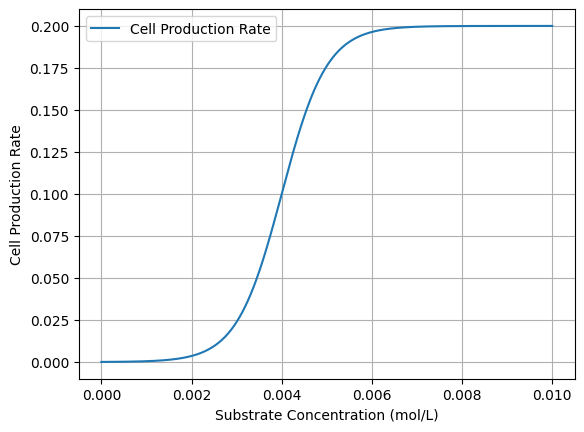

6.707002609329562e-05


In [175]:
import numpy as np

def cell_production_rate(sub_conc, R_max=0.20, S_0=0.004, k=2000):
    """
    Calculate the rate of cell production based on a sigmoid curve.

    Parameters:
    sub_conc (float): Substrate concentration (mol/L).
    R_max (float): Maximum rate of cell production (default is 0.20).
    S_0 (float): Midpoint substrate concentration, where rate is half of R_max (default is 0.025 mol/L).
    k (float): Steepness of the curve. A higher value makes the curve steeper (default is 50).

    Returns:
    float: Rate of cell production.
    """
    # Sigmoid curve formula for rate of cell production
    rate = R_max / (1 + np.exp(-k * (sub_conc - S_0)))
    return rate

rates = []
# Example: Test with a substrate concentration
substrate_concentrations = np.linspace(0, 0.010, 500)

for i in substrate_concentrations:
    rate = cell_production_rate(i)
    rates.append(rate)

# Plot the logistic function
plt.plot(substrate_concentrations, rates, label='Cell Production Rate')
plt.xlabel('Substrate Concentration (mol/L)')
plt.ylabel('Cell Production Rate')
plt.grid(True)
plt.legend()
plt.show()

print(cell_production_rate(0))



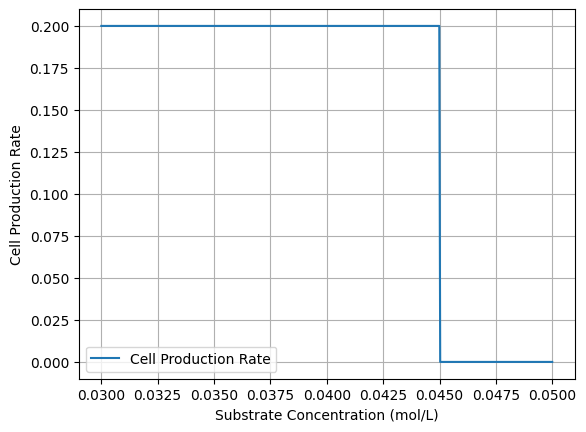

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rates = []
# Example: Test with a substrate concentration
substrate_concentrations = np.linspace(0.03, 0.05, 500)

for i in substrate_concentrations:
    if i < 0.001 or i > 0.045:
        MuX = 0
    else:
        MuX = 0.2
    rates.append(MuX)

# Plot the logistic function
plt.plot(substrate_concentrations, rates, label='Cell Production Rate')
plt.xlabel('Substrate Concentration (mol/L)')
plt.ylabel('Cell Production Rate')
plt.grid(True)
plt.legend()
plt.show()